# Importação de Bibliotecas

In [ ]:
# Instalações Necessárias
!pip install langdetect

In [ ]:
# Processamento de Linguagem Natural (PLN)
from langdetect import detect
import spacy

# Controle de Arquivos
import json
import os

# Controle de dataset
import pandas as pd

# Visualização de Dados
import matplotlib.pyplot as plt

# Computação Numérica
import numpy as np

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 20.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=e375ef02d526f910fa35203a009b32776fa7c7ff8d8c8fb02007a5b973ff67ca
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


## Caminhos de Arquivos

In [ ]:
# Altere os caminhos conforme necessário

# Raíz do corpus SteamBR
path_raiz_steamcorpusbr = "drive/MyDrive/TCC/steambrcorpus/reviews_filtradas"

# Arquivo pickle de saída
path_output_file = "df_pt.pkl"

# Importar Dataset

In [ ]:
all_rows = []

for root, dirs, files in os.walk(path_raiz_steamcorpusbr):
  for file in files:
    if file.endswith(".json"):
      with open(os.path.join(root, file), "r", encoding="utf-8") as f:
        data = json.load(f)

      if "reviews" not in data:
        print("Sem 'reviews':", file)
        continue

      for review_id, review_data in data["reviews"].items():
        row = review_data.copy()
        row["review_id"] = review_id
        row["game"] = file

        author = row.pop("author")
        for k, v in author.items():
            row[f"author_{k}"] = v

        all_rows.append(row)

df = pd.DataFrame(all_rows)

Sem 'reviews': FPS_json_part50.json
Sem 'reviews': FPS_json_rest_part_50.json
Sem 'reviews': Adventure_json_part50.json
Sem 'reviews': Adventure_json_rest_part_50.json
Sem 'reviews': Action_json_part50.json
Sem 'reviews': Horror_json_part50.json
Sem 'reviews': Horror_json_rest_part_50.json
Sem 'reviews': Indie_json_part50.json
Sem 'reviews': Indie_json_rest_part_50.json
Sem 'reviews': RPG_json_part50.json
Sem 'reviews': RPG_json_rest_part_50.json
Sem 'reviews': Simulation_json_part50.json
Sem 'reviews': Simulation_json_rest_part_50.json
Sem 'reviews': Sports_json_part50.json
Sem 'reviews': Sports_json_rest_part_50.json
Sem 'reviews': Strategy_json_part50.json
Sem 'reviews': Strategy_json_rest_part_50.json


In [ ]:
df.shape

(2777509, 24)

# Filtragem de Reviews

In [ ]:
df_filtered = df[df["votes_up"] >=3]

In [ ]:
df_filtered.shape

(233993, 24)

# Votos em log base 10 para facilitar visualização

In [ ]:
df["votes_log"] = np.log1p(df["votes_up"])
df_filtered["votes_log"] = np.log1p(df_filtered["votes_up"])

/tmp/ipykernel_3476/1266440320.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["votes_log"] = np.log1p(df_filtered["votes_up"])


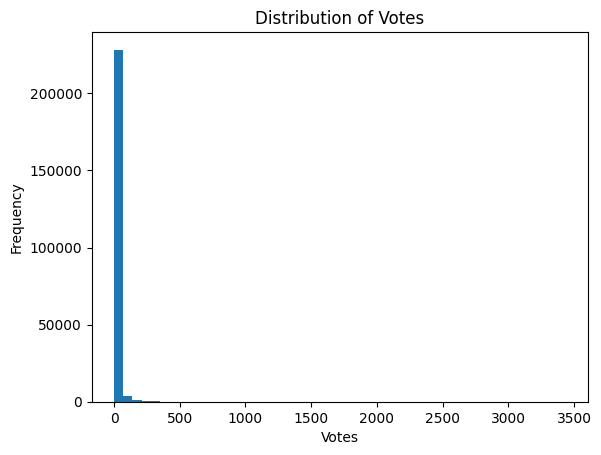

In [ ]:
plt.figure()
plt.hist(df_filtered["votes_up"], bins=50)
plt.xlabel("Votes")
plt.ylabel("Frequency")
plt.title("Distribution of Votes")
plt.show()

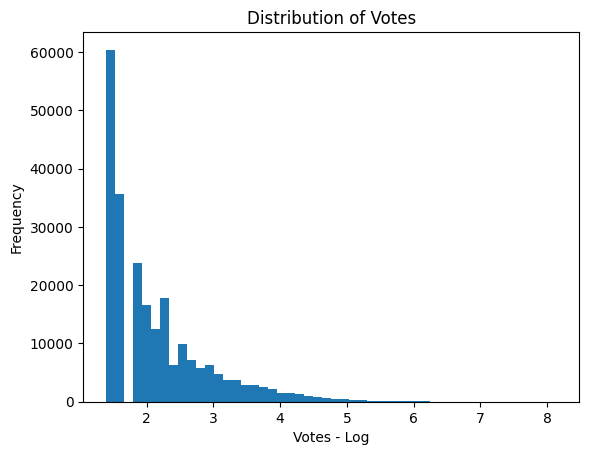

In [ ]:
plt.figure()
plt.hist(df_filtered["votes_log"], bins=50)
plt.xlabel("Votes - Log")
plt.ylabel("Frequency")
plt.title("Distribution of Votes")
plt.show()

# Detecção de Linguagem

In [ ]:
spacy.cli.download("pt_core_news_sm")

✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
def is_portuguese(text):
  try:
    return detect(text) == "pt"
  except:
    return False

df_filtered["is_pt"] = df_filtered["review"].apply(is_portuguese)

/tmp/ipykernel_3476/2577903611.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["is_pt"] = df_filtered["review"].apply(is_portuguese)


In [ ]:
df_not_pt = df_filtered[df_filtered["is_pt"] == False]
df_pt = df_filtered[df_filtered["is_pt"]]

In [ ]:
df_pt.shape

(202916, 26)

In [ ]:
df_not_pt.shape

(31077, 26)

# Download de Dataset Pré-Processado

In [ ]:
df_pt.to_pickle(path_output_file)